# Which Side Wins, Red or Blue?

**Name(s)**: Milo Palmquist, and Shriya Pattapu

**Website Link**: https://spattapu1.github.io/LoL-Statistical-Analysis/

In [49]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
pd.options.plotting.backend = 'plotly'
import sklearn as sk

from dsc80_utils import * # Feel free to uncomment and use this.
from scipy import stats
pio.renderers.default = 'notebook_connected'


## Step 1: Introduction

#### Posited Questions: 

- **Are you more likely perform better if you are on the blue side or red side?**
- Does having a champion with a high ban rate on your increase the likelihood of winning?
- Does bot draw firstblood more than other positions? 

 *Bolded question is the one we chose. 

## Step 2: Data Cleaning and Exploratory Data Analysis

### Data Cleaning

In [50]:
# Load the original data
df = pd.read_csv("main.csv", low_memory=False)

In [51]:
# Only keep the rows where the datacompleteness is 'complete'
complete = df[df['datacompleteness'] == 'complete']

# Convert the gamelength column to a datetime object for readability
#complete['gamelength'] = pd.to_datetime(complete['gamelength'], unit= 's').dt.time
complete['gamelength'] = complete['gamelength'] / 60

# Only keep the columns that are relevant to the analysis, and reset the index
complete_teams = complete.loc[complete['position'] == 'team']
teams = complete_teams[['gameid'
                        ,'league'
                        ,'side'
                        ,'teamname'
                        , 'gamelength'
                        , 'result'
                        , 'teamkills'
                        , 'earnedgold'
                        , 'damagetochampions'
                        , 'xpat25'
                        , 'csat25'
                        , 'dragons'
                        , 'barons']].reset_index(drop=True)
teams.head()


,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
0,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
1,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
2,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
3,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
4,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


### Univariate Analysis 

In [52]:
# Distribution of Team Kills per Team
fig = px.histogram(teams, x='teamkills')
fig.update_layout(
    title='Distribution of Team Kills per Team',
    xaxis_title='Number of Team Kills',
    yaxis_title='Count'
)

In [53]:
# Distribution of Earned Gold per Team
fig = px.histogram(teams, x='earnedgold')
fig.update_layout(
    title='Distribution of Earned Gold per Team',
    xaxis_title='Amount of Earned Gold',
    yaxis_title= 'Count'
)

### Bivariate Analysis

In [54]:
# Distribution of Total Kills per Team by Side
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['teamkills'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['teamkills'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.50)
fig.update_layout(yaxis_title="Count")
fig.update_layout(xaxis_title="Total Kills")
fig.update_layout(title="Total Kills by Side")
fig.show()

In [55]:
# Distribution of Earned Gold per Team by Side
fig = go.Figure()
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Red']['earnedgold'], name='Red',marker_color='red'))
fig.add_trace(go.Histogram(x=teams[teams['side'] == 'Blue']['earnedgold'], name='Blue',marker_color='blue'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.50)
fig.update_layout(yaxis_title="Count")
fig.update_layout(xaxis_title="Total Earned Gold")
fig.update_layout(title="Total Earned Gold by Side")
fig.show()

### Intresting Aggregates

In [56]:
# Grouping the data by league and side
teams.groupby(['league', 'side'])[['result', 'teamkills','earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']].mean()

result  teamkills  earnedgold  damagetochampions    xpat25  \
league side                                                               
CBLOL  Blue    0.54      14.73    37677.15           67642.06  51564.81   
       Red     0.46      13.76    36747.37           66220.88  51371.28   
CBLOLA Blue    0.55      14.55    37296.72           67311.03  51236.61   
...             ...        ...         ...                ...       ...   
VL     Red     0.54      15.26    35772.41           65774.69  52088.25   
WLDs   Blue    0.53      12.87    36133.45           68238.09  51742.65   
       Red     0.47      12.99    35839.08           66783.12  51540.04   

             csat25  dragons  barons  
league side                           
CBLOL  Blue  823.41     2.18    0.74  
       Red   829.91     2.44    0.68  
CBLOLA Blue  819.71     2.15    0.74  
...             ...      ...     ...  
VL     Red   805.31     2.35    0.69  
WLDs   Blue  830.43     1.94    0.68  
       Red   826.78     2.28    0.67  

[102 rows x 8 columns]

In [57]:
# Groupby the data by gameid and side
teams.groupby(['gameid', 'side'])[['result', 'teamkills','earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']].mean()

result  teamkills  earnedgold  damagetochampions  \
gameid                side                                                     
ESPORTSTMNT01_2690210 Blue     0.0        9.0     28222.0            56560.0   
                      Red      1.0       19.0     33769.0            79912.0   
ESPORTSTMNT01_2690219 Blue     0.0        3.0     34688.0            59579.0   
...                            ...        ...         ...                ...   
NA1_4493652706        Red      0.0       11.0     22602.0            47157.0   
NA1_4493722220        Blue     0.0       13.0     34657.0            73865.0   
                      Red      1.0       28.0     44015.0            89429.0   

                             xpat25  csat25  dragons  barons  
gameid                side                                    
ESPORTSTMNT01_2690210 Blue  45960.0   767.0      1.0     0.0  
                      Red   49931.0   864.0      3.0     0.0  
ESPORTSTMNT01_2690219 Blue  49409.0   895.0      1.0     0.0  
...                             ...     ...      ...     ...  
NA1_4493652706        Red       NaN     NaN      1.0     0.0  
NA1_4493722220        Blue  51930.0   800.0      0.0     0.0  
                      Red   54461.0   760.0      3.0     2.0  

[21312 rows x 8 columns]

In [58]:
# Groupby the data by side
# Add to final report.
teams.groupby('side')[['result', 'teamkills','earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']].mean()


,result,teamkills,earnedgold,damagetochampions,xpat25,csat25,dragons,barons
side,,,,,,,,
Blue,0.52,14.87,36566.61,67612.10,51893.28,820.96,2.14,0.67
Red,0.48,14.32,35947.70,66651.46,51831.29,822.53,2.35,0.68


## Step 3: Assessment of Missingness

In [59]:
xpat25_notna = teams[teams['xpat25'].isna() == False]
xpat25_notna.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
0,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
1,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
2,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
3,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
4,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [60]:
xpat25_na = teams[teams['xpat25'].isna() == True]
xpat25_na.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
24,ESPORTSTMNT01_2700475,LVP SL,Blue,Barça eSports,...,NaN,NaN,0.0,0.0
25,ESPORTSTMNT01_2700475,LVP SL,Red,KOI,...,NaN,NaN,3.0,0.0
34,NA1_4170925713,PGC,Blue,Goose Gaming,...,NaN,NaN,0.0,0.0
35,NA1_4170925713,PGC,Red,Bay State College,...,NaN,NaN,3.0,1.0
38,NA1_4170786291,PGC,Blue,Golden Guardians Academy,...,NaN,NaN,2.0,0.0


In [61]:
# Distribution of xpat25
xpat25_dist = (
    teams
    .assign(xpat_missing=teams['xpat25'].isna())
    .pivot_table(index='gamelength', columns='xpat_missing', aggfunc='size')
)

xpat25_dist.columns = ['xpat_missing = False', 'xpat_missing = True']
xpat25_dist = xpat25_dist / xpat25_dist.sum()
xpat25_dist = xpat25_dist.fillna(0)

In [62]:

fig = go.Figure()
fig.add_trace(go.Histogram(
    x=xpat25_notna['gamelength'],  # Use total seconds for the histogram
    name='Not Missing',
    marker_color='red',
    nbinsx=int(xpat25_notna['gamelength'].max() - xpat25_notna['gamelength'].min())  # Dynamic bins based on range
))

fig.add_trace(go.Histogram(
    x=xpat25_na['gamelength'],  # Use total seconds for the histogram
    name='Missing',
    marker_color='blue',
    nbinsx=int(xpat25_na['gamelength'].max() - xpat25_na['gamelength'].min())  # Dynamic bins based on range
))

fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.55)
fig.update_layout(yaxis_title="count")
fig.update_layout(xaxis_title="Game Length (minutes)")
fig.update_layout(title="Game Length by Missingness of xpat25")
fig

In [63]:
observed_ks = stats.ks_2samp(xpat25_notna['gamelength'], xpat25_na['gamelength']).statistic
observed_ks

np.float64(0.992025507599341)

In [64]:
shuffled = teams.copy()

ks_stats = []
for _ in range(1000):
    
    shuffled['gamelength'] = np.random.permutation(shuffled['gamelength'])
    
    ks_stat = stats.ks_2samp(shuffled[shuffled['xpat25'].isna() == False]['gamelength'], shuffled[shuffled['xpat25'].isna() == True]['gamelength']).statistic
    ks_stats.append(ks_stat)

ks_stats[:10]

[np.float64(0.02844864242798148),
 np.float64(0.02752232610914368),
 np.float64(0.013650481051375757),
 np.float64(0.011755641077795809),
 np.float64(0.033601080507799086),
 np.float64(0.017822721106945716),
 np.float64(0.015171741200780797),
 np.float64(0.03882042170516742),
 np.float64(0.03639664299014728),
 np.float64(0.04543170695895693)]

In [65]:
fig = px.histogram(pd.DataFrame(ks_stats), x=0, nbins=50, histnorm='probability', 
                   title='Empirical Distribution of the K-S Statistic')
fig.add_vline(x=observed_ks, line_color='red', line_width=1, opacity=1)
fig.add_annotation(text=f'<span style="color:red">Observed KS = {round(observed_ks, 2)}</span>',
                   x=0.8 * observed_ks, showarrow=False, y=0.16)
fig.update_layout(xaxis_range=[0, 0.2])
fig.update_layout(yaxis_range=[0, 0.2])

In [66]:
ks_pval = (ks_stats >= observed_ks).mean()
ks_pval

np.float64(0.0)

In [67]:
side_dist = (
    teams
    .assign(xpat25_missing=teams['xpat25'].isna())
    .pivot_table(index='side', columns='xpat25_missing', aggfunc='size')
)

side_dist.columns = ['xpat25_missing = False', 'xpat25_missing = True']

side_dist = side_dist / side_dist.sum()
side_dist

,xpat25_missing = False,xpat25_missing = True
side,,
Blue,0.5,0.5
Red,0.5,0.5


In [68]:
side_dist.plot(kind='barh', title='Side by Missingness of xpat25', barmode='group')


In [69]:
observed_tvd = np.float64(sum(abs(side_dist['xpat25_missing = False'] - side_dist['xpat25_missing = True']))/2)
observed_tvd

np.float64(0.0)

In [70]:
shuffled = teams.copy()

tvds = []
for i in range(1000):

    shuffled['side'] = np.random.permutation(shuffled['side'])

    side_dist = (
        shuffled
        .assign(xpat25_missing=teams['xpat25'].isna())
        .pivot_table(index='side', columns='xpat25_missing', aggfunc='size')
    )

    side_dist.columns = ['xpat25_missing = False', 'xpat25_missing = True']

    side_dist = side_dist / side_dist.sum()
    tvd = sum(abs(side_dist['xpat25_missing = False'] - side_dist['xpat25_missing = True']))/2
    tvds.append(tvd)

tvds[:10]

[0.003987246200329447,
 0.0007974492400659172,
 0.003987246200329447,
 0.001594898480131779,
 0.0031897969602636134,
 0.010366840120856674,
 0.03429031732283361,
 0.0071770431605930884,
 0.02711327416224052,
 0.023923477201976878]

In [71]:
fig = px.histogram(pd.DataFrame(tvds), x=0, nbins=50, histnorm='probability', 
                   title='Empirical Distribution of the TVD')
fig.add_vline(x=observed_tvd, line_color='red', line_width=2, opacity=1)
fig.add_annotation(text=f'<span style="color:red">Observed TVD = {round(observed_tvd, 3)}</span>',
                   x=2.5 * observed_tvd, showarrow=False, y=0.16)
fig.update_layout(yaxis_range=[0, 0.2])

In [72]:
tvd_pval = (tvds >= observed_tvd).mean()
tvd_pval

np.float64(1.0)

## Step 4: Hypothesis Testing

**Null Hypothesis**: Team kills of teams on the blue side and teams on the red side have the same distribution.

**Alternative Hypothesis**: Team kills of teams on the blue side and teams on the red side are distributed differently.

**Test-Statistic**: Difference in Means of team kills for blue side and team kills for red side.


In [73]:
shuffled = teams.copy()

perm_dist = []
for i in range(1000):
    shuffled['side'] = np.random.permutation(shuffled['side'])
    by_side = shuffled.groupby('side')['teamkills'].mean()
    perm_dist.append(by_side['Blue'] - by_side['Red'])

perm_dist = pd.DataFrame(perm_dist, columns=["Difference in Means of Team Kills (Blue - Red)"])
perm_dist.head()

,Difference in Means of Team Kills (Blue - Red)
0,0.04
1,-0.04
2,0.03
3,0.18
4,-0.10


In [74]:
observed = teams.groupby('side')['teamkills'].mean().loc['Blue'] - teams.groupby('side')['teamkills'].mean().loc['Red']
p_val = ((perm_dist['Difference in Means of Team Kills (Blue - Red)']) >= observed).mean()
p_val

np.float64(0.0)

In [75]:
fig = px.histogram(perm_dist, 'Difference in Means of Team Kills (Blue - Red)')
fig.update_layout(yaxis_title="Count")
fig.update_layout(xaxis_title="Difference in Means of Team Kills (Blue - Red)")
fig.update_layout(title={
        'text': "Empirical Distribution of the Difference in Means of Team Kills (Blue - Red)",
        'font': {'size': 14}
    })
fig.add_vline(x=observed, line_color='red', line_width=2, opacity=1)
fig.show()

## Step 5: Framing a Prediction Problem

Our prediction problem, which is: Based on the difference in in-game statistics can we predict wether the winning side of a game was blue or red?. This allows for our classification model to have more accurate measures of differences between sides as apposed to general in-game statistics that are not in relation to the other side. Thus our response variable is wether the winner was red or blue which is included in the differences between team statistics dataframe. 

## Step 6: Baseline Model

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

In [77]:
X_train, X_test, y_train, y_test = (
    train_test_split(teams[['teamkills', 'earnedgold']], teams['side'], random_state=1)
)

dtb_pl = sk.pipeline.Pipeline([('model', DecisionTreeClassifier(max_depth=4, criterion='entropy'))])
dtb_pl.fit(X_train, y_train)

dtb_pl.score(X_train, y_train), dtb_pl.score(X_test, y_test)

(0.5259634634634635, 0.5152027027027027)

### Base Model w/ Random Forest Classifier based on the in-game statistics can we predict wether the winning side of a game was blue or red

In [78]:
at_least_25 = complete_teams[complete_teams['gamelength'] >= 25][['gameid'
                                                                  ,'league'
                                                                  ,'side'
                                                                  ,'teamname'
                                                                  ,'result'
                                                                  , 'teamkills'
                                                                  , 'earnedgold'
                                                                  , 'damagetochampions'
                                                                  , 'xpat25'
                                                                  , 'csat25'
                                                                  , 'dragons'
                                                                  , 'barons']].reset_index(drop=True).dropna()
at_least_25.head()

,gameid,league,side,teamname,...,xpat25,csat25,dragons,barons
0,ESPORTSTMNT01_2690210,LCKC,Blue,BRION Challengers,...,45960.0,767.0,1.0,0.0
1,ESPORTSTMNT01_2690210,LCKC,Red,Nongshim Esports Academy,...,49931.0,864.0,3.0,0.0
2,ESPORTSTMNT01_2690219,LCKC,Blue,T1 Esports Academy,...,49409.0,895.0,1.0,0.0
3,ESPORTSTMNT01_2690219,LCKC,Red,Liiv SANDBOX Youth,...,57155.0,928.0,4.0,2.0
4,ESPORTSTMNT01_2690227,LCKC,Blue,KT Rolster Challengers,...,52441.0,912.0,4.0,1.0


In [79]:
at_least_25['winner'] = at_least_25.apply(lambda row: row['side'] if row['result'] == 1 else ('Red' if row['side'] == 'Blue' else 'Blue'), axis=1)

In [80]:
X_raw = at_least_25[['teamkills', 'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons', 'barons']]
y_raw = at_least_25['winner']

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, random_state=1)

raw_pl = sk.pipeline.Pipeline([('model', RandomForestClassifier())])

raw_pl.fit(X_train, y_train)

Pipeline(steps=[('model', RandomForestClassifier())])

In [81]:
raw_pl.score(X_train, y_train), raw_pl.score(X_test, y_test)

(1.0, 0.5517819706498952)

### Base Model w/ Random Forest Classifier based on the difference in teamkills and earned gold can we predict wether the winning side of a game was blue or red

this is final basline model

In [82]:
#Preprocessing
diffs_df = at_least_25.drop(columns=['league', 'side', 'teamname', 'result']).groupby('gameid')[['teamkills',
       'earnedgold', 'damagetochampions', 'xpat25', 'csat25', 'dragons',
       'barons']].diff() * -1

diffs_df['gameid'] = at_least_25['gameid']

diffs_df = diffs_df.dropna()

winners = at_least_25[at_least_25['result'] == 1][['gameid', 'side']]
diffs_df = diffs_df.merge(winners, how='inner', on='gameid').set_index('gameid')
diffs_df = diffs_df.rename(columns={'side': 'winner'})

diffs_df

,teamkills,earnedgold,damagetochampions,xpat25,csat25,dragons,barons,winner
gameid,,,,,,,,
ESPORTSTMNT01_2690210,-10.0,-5547.0,-23352.0,-3971.0,-97.0,-2.0,-0.0,Red
ESPORTSTMNT01_2690219,-13.0,-13375.0,-15276.0,-7746.0,-33.0,-3.0,-2.0,Red
ESPORTSTMNT01_2690227,9.0,10691.0,21256.0,2532.0,5.0,3.0,1.0,Blue
...,...,...,...,...,...,...,...,...
ESPORTSTMNT01_3268686,-16.0,-10325.0,-22161.0,5476.0,129.0,-2.0,-1.0,Red
ESPORTSTMNT01_3269631,10.0,8771.0,2804.0,-899.0,-48.0,-1.0,-0.0,Blue
ESPORTSTMNT01_3268705,13.0,15074.0,33121.0,2143.0,30.0,4.0,1.0,Blue


In [83]:
X_train, X_test, y_train, y_test = train_test_split(diffs_df[['teamkills', 'earnedgold']], diffs_df['winner'], random_state=1)
base_diff_pl = sk.pipeline.Pipeline([('model', RandomForestClassifier())])
base_diff_pl.fit(X_train, y_train)


Pipeline(steps=[('model', RandomForestClassifier())])

In [84]:
# This model is actually really good. Differences make a lot of difference lol. 
base_diff_pl.score(X_train, y_train), base_diff_pl.score(X_test, y_test)

(1.0, 0.9735849056603774)

In [85]:
metrics.f1_score(y_test, base_diff_pl.predict(X_test), average= 'weighted')

np.float64(0.9735857416068037)

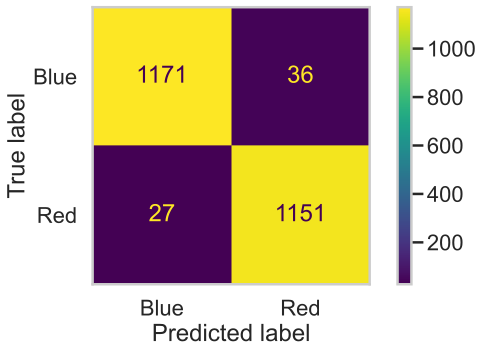

In [86]:
# Predict the test data
y_pred = base_diff_pl.predict(X_test)
# Plot the confusion matrix
metrics.confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_estimator(base_diff_pl, X_test, y_test);
plt.grid(False)

## Step 7: Final Model

### Final Model w/ Decision Tree

In [87]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = (
    train_test_split(diffs_df.drop(columns='winner'), diffs_df['winner'], random_state=1)
)

# Fit the decision tree model
final_dtf_pl = sk.pipeline.Pipeline([('model', DecisionTreeClassifier(max_depth=4, criterion='entropy'))])
final_dtf_pl.fit(X_train, y_train)

Pipeline(steps=[('model',
                 DecisionTreeClassifier(criterion='entropy', max_depth=4))])

In [88]:
# Calculate the accuracy of the model
final_dtf_pl.score(X_train, y_train), final_dtf_pl.score(X_test, y_test)

(0.9830816554809844, 0.9731656184486374)

### Grid Search for Best Hyperparameters for DecisionTree

In [89]:
# Grid search for best hyperparameters
# Update the hyperparameters dictionary to things that actually matter.  
hyperparameters = {
    'max_depth': [2, 3, 4, 5, 7, 10, 13, 15, 18, None], 
    'min_samples_split': [2, 5, 10, 20, 50, 100, 200],
    'criterion': ['gini', 'entropy'],

}

len(hyperparameters['max_depth']) * \
len(hyperparameters['min_samples_split']) * \
len(hyperparameters['criterion'])

searcher = GridSearchCV(DecisionTreeClassifier(), hyperparameters, cv=5)
searcher.fit(X_train, y_train)
searcher.best_params_

{'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 10}

In [90]:
# Fit the best model
best_dtc_pl = sk.pipeline.Pipeline([('model', DecisionTreeClassifier(**searcher.best_params_))])
best_dtc_pl.fit(X_train, y_train)
best_dtc_pl.score(X_train, y_train), best_dtc_pl.score(X_test, y_test)

(0.9848993288590604, 0.979454926624738)

### Final Model w/ Random Forest Classifier

this is final final model

In [91]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = (
    train_test_split(diffs_df.drop(columns=['winner']), diffs_df['winner'], random_state=1)
)
# Fit the random forest model
final_rfc_pl = sk.pipeline.Pipeline([('model',RandomForestClassifier())])
final_rfc_pl.fit(X_train, y_train)

Pipeline(steps=[('model', RandomForestClassifier())])

In [92]:
# Calculate the accuracy of the model
final_rfc_pl.score(X_train, y_train) , final_rfc_pl.score(X_test, y_test)

(1.0, 0.9823899371069182)

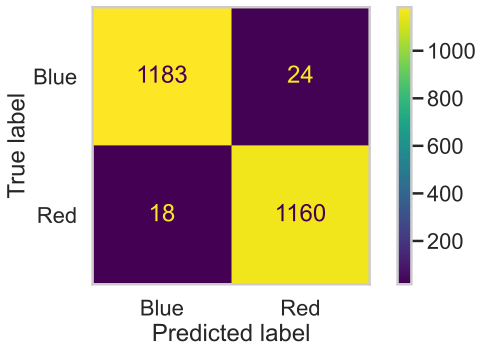

In [93]:
# Predict the test data
y_pred = final_rfc_pl.predict(X_test)
# Plot the confusion matrix
metrics.confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_estimator(final_rfc_pl, X_test, y_test);
plt.grid(False)

In [94]:
# Model Evaluation Scores
metrics.accuracy_score(y_test, final_rfc_pl.predict(X_test))

0.9823899371069182

In [95]:
metrics.f1_score(y_test, final_rfc_pl.predict(X_test), average= 'weighted')

np.float64(0.9823903643781153)

### Grid Search for Best Hyperparameters for RandomForestClassifier

In [96]:
hyperparameters = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [2, 5, 10, 15, 20, 25, None],
}


In [97]:
searcher = GridSearchCV(RandomForestClassifier(), hyperparameters, cv=5)
searcher.fit(X_train, y_train)
searcher.best_params_

{'max_depth': 10, 'n_estimators': 300}

In [98]:
best_rfc_pl = sk.pipeline.Pipeline([('model', RandomForestClassifier(**searcher.best_params_))])
best_rfc_pl.fit(X_train, y_train)
best_rfc_pl.score(X_train, y_train), best_rfc_pl.score(X_test, y_test)

(0.9967841163310962, 0.9832285115303984)

In [99]:
metrics.f1_score(y_test, best_rfc_pl.predict(X_test), average= 'weighted')

np.float64(0.9832288064085274)

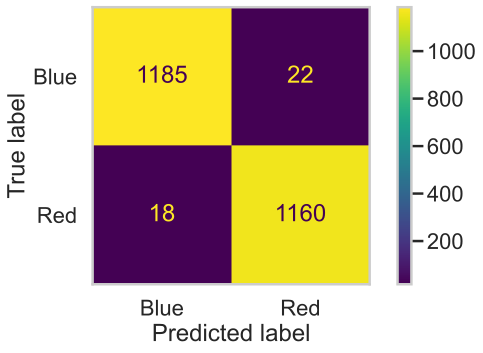

In [100]:
# Predict the test data
y_pred = best_rfc_pl.predict(X_test)
# Plot the confusion matrix
metrics.confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_estimator(best_rfc_pl, X_test, y_test);
plt.grid(False)

## Step 8: Fairness Analysis

Does our model perform suboptimally for games played in the Korean leagues compared to other leagues?

**Null Hypothesis:** Our model is fair, and its accuracy between games played in the Korean leagues and games played in the others leagues is the same.

**Alternative Hypothesis:** Our model is not fair, and its accuracy for games played in the Korean leagues are greater then for games not in the LCK league. 

**Test-Stat:** Difference in accuracy (Not Korean - Korean)

In [101]:
# We use the original data since the test set it very small
results = diffs_df.copy()
results['predicted winner'] = best_rfc_pl.predict(diffs_df.drop(columns='winner'))
results = results.merge(teams[teams['gameid'].isin(results.index)][['gameid','league']], on = 'gameid', how = 'left')
results['is_Korean'] = results['league'].isin(['LCK', 'LCKC'])
#results.drop(columns='league', inplace=True)
results['is_Korean'].value_counts()
results.drop_duplicates(inplace=True)
results.set_index('gameid', inplace=True)

In [102]:
compute_accuracy = lambda x: metrics.accuracy_score(x['winner'], x['predicted winner'].values)

obs = results.groupby('is_Korean')[['winner', 'predicted winner']].apply(compute_accuracy).diff().iloc[-1]

diff_in_acc = []
for i in range(100):
    shuffled_results = results.copy()
    s = (
        shuffled_results[['is_Korean', 'predicted winner', 'winner']]
        .assign(is_Korean=np.random.permutation(results['is_Korean']))
        .groupby('is_Korean')
        [['winner', 'predicted winner']]
        .apply(compute_accuracy)
        .diff()
        .iloc[-1]
    )
    diff_in_acc.append(s)

p_value = np.mean(np.abs(diff_in_acc) >= np.abs(obs))
p_value

np.float64(1.0)

In [103]:
fig  = pd.Series(diff_in_acc).plot(kind='hist', histnorm='probability', nbins=20,
                            title='Difference in Accuracy (Not Korean - Is Korean)')
fig.update_layout(xaxis_range=[-0.008, 0.008])
fig.add_vline(x=obs, line_color='red', line_width=2, opacity=1)

In [107]:
fig.write_html('assets/fairness.html', include_plotlyjs='cdn')